In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the correct path to the dataset
data_file_path = '/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv'

try:
    df = pd.read_csv(data_file_path)
    print("Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: Data file not found at {data_file_path}. Please ensure the file exists.")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")

Dataset loaded successfully!


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [8]:
# Display basic information about the dataset
print("\nDataset Information:")
df.info()

# Check for missing values
print("\nMissing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Handle missing values: fill numerical NaNs with mean, categorical with mode
for column in df.columns:
    if df[column].isnull().any():
        if df[column].dtype in ['int64', 'float64']:
            print(f"Filling missing numerical values in '{column}' with its mean.")
            df[column].fillna(df[column].mean(), inplace=True)
        elif df[column].dtype == 'object':
            print(f"Filling missing categorical values in '{column}' with its mode[0].")
            df[column].fillna(df[column].mode()[0], inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum().sum())

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  ad

/tmp/ipykernel_3338/1286498713.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000



Box plots for numerical features (Outlier Identification):


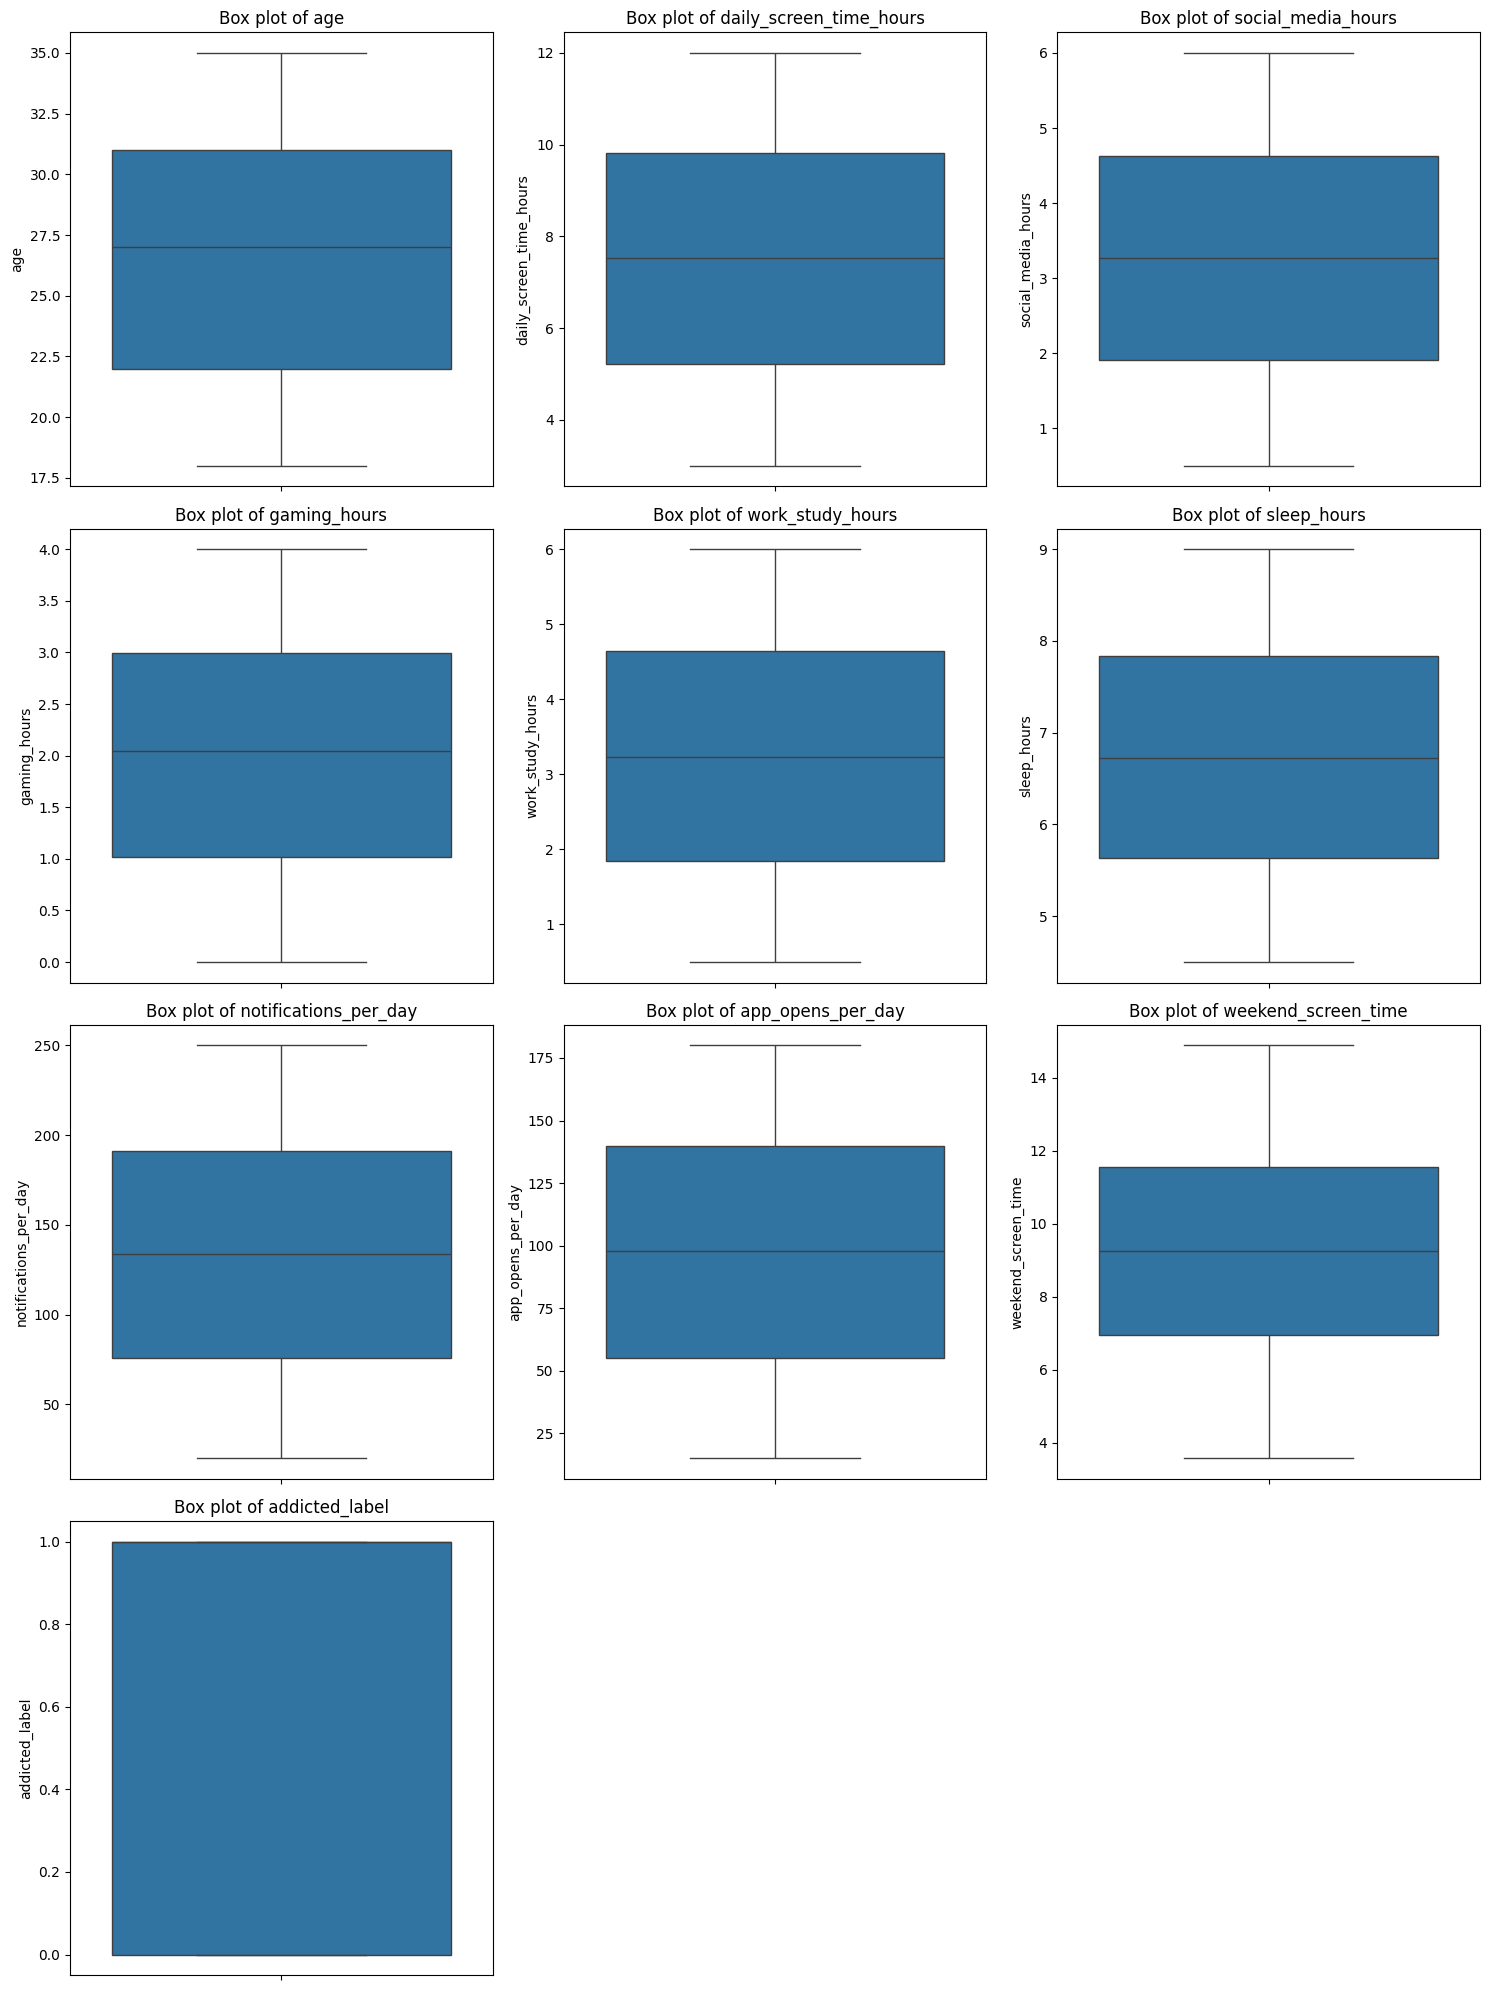

In [9]:
# Identify numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['number']).columns

if not numerical_cols.empty:
    print("\nBox plots for numerical features (Outlier Identification):")
    # Determine the number of rows needed for the subplots
    num_rows = (len(numerical_cols) + 2) // 3 # Roughly 3 columns per row
    plt.figure(figsize=(15, 5 * num_rows))
    for i, col in enumerate(numerical_cols):
        plt.subplot(num_rows, 3, i + 1)
        sns.boxplot(y=df[col])
        plt.title(f'Box plot of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found for outlier identification.")


Histograms for numerical features:


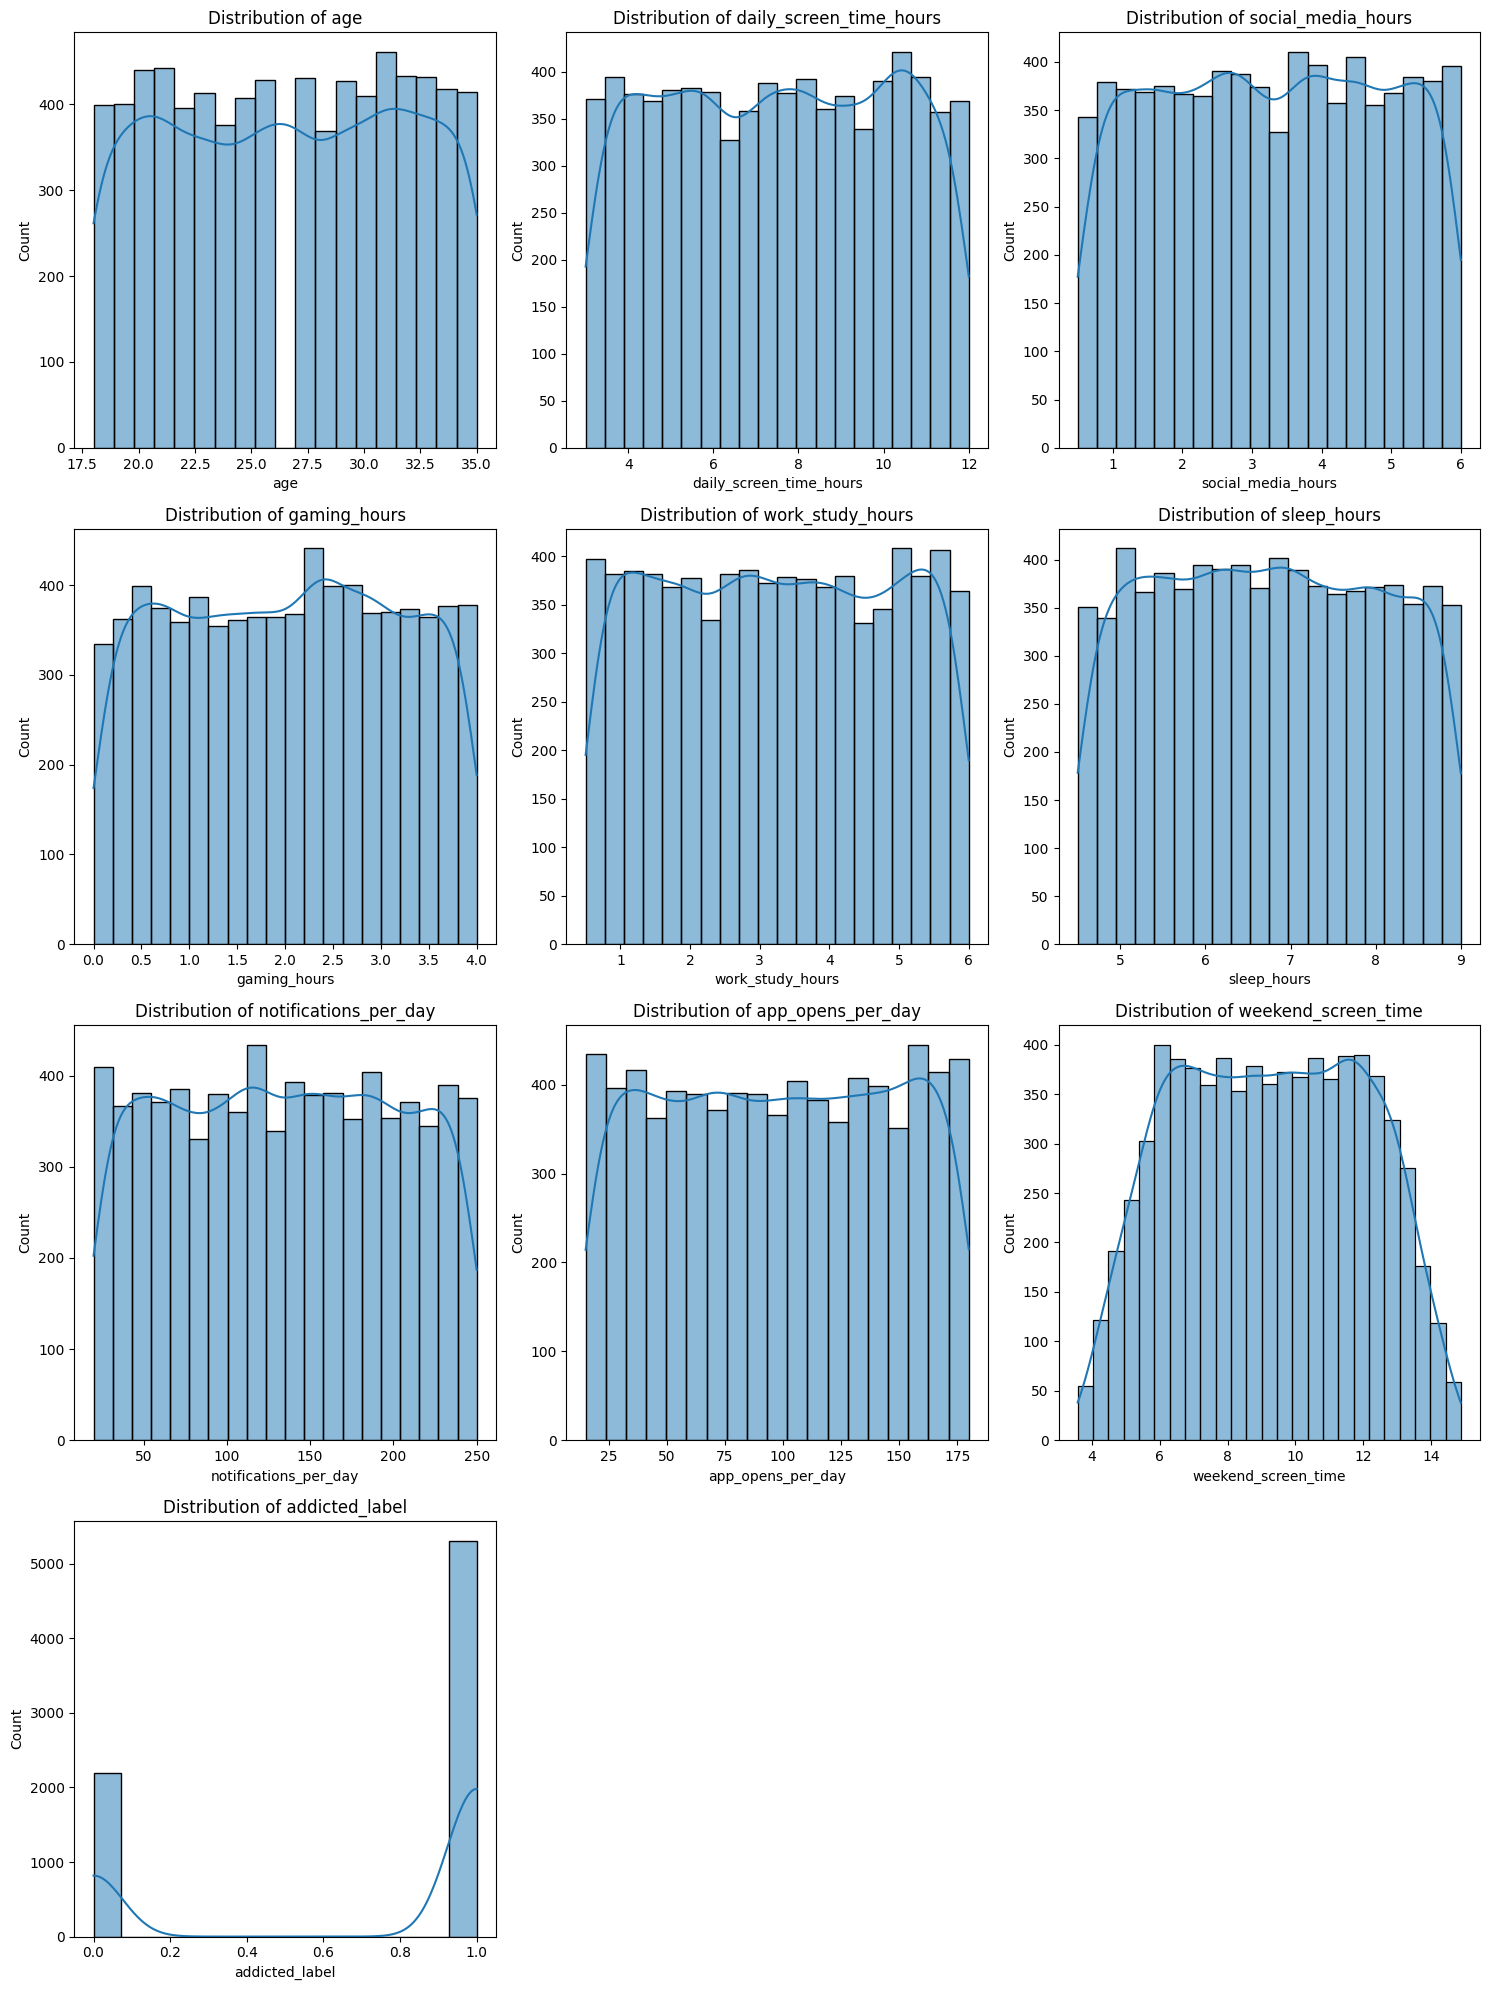


Bar plots for categorical features:


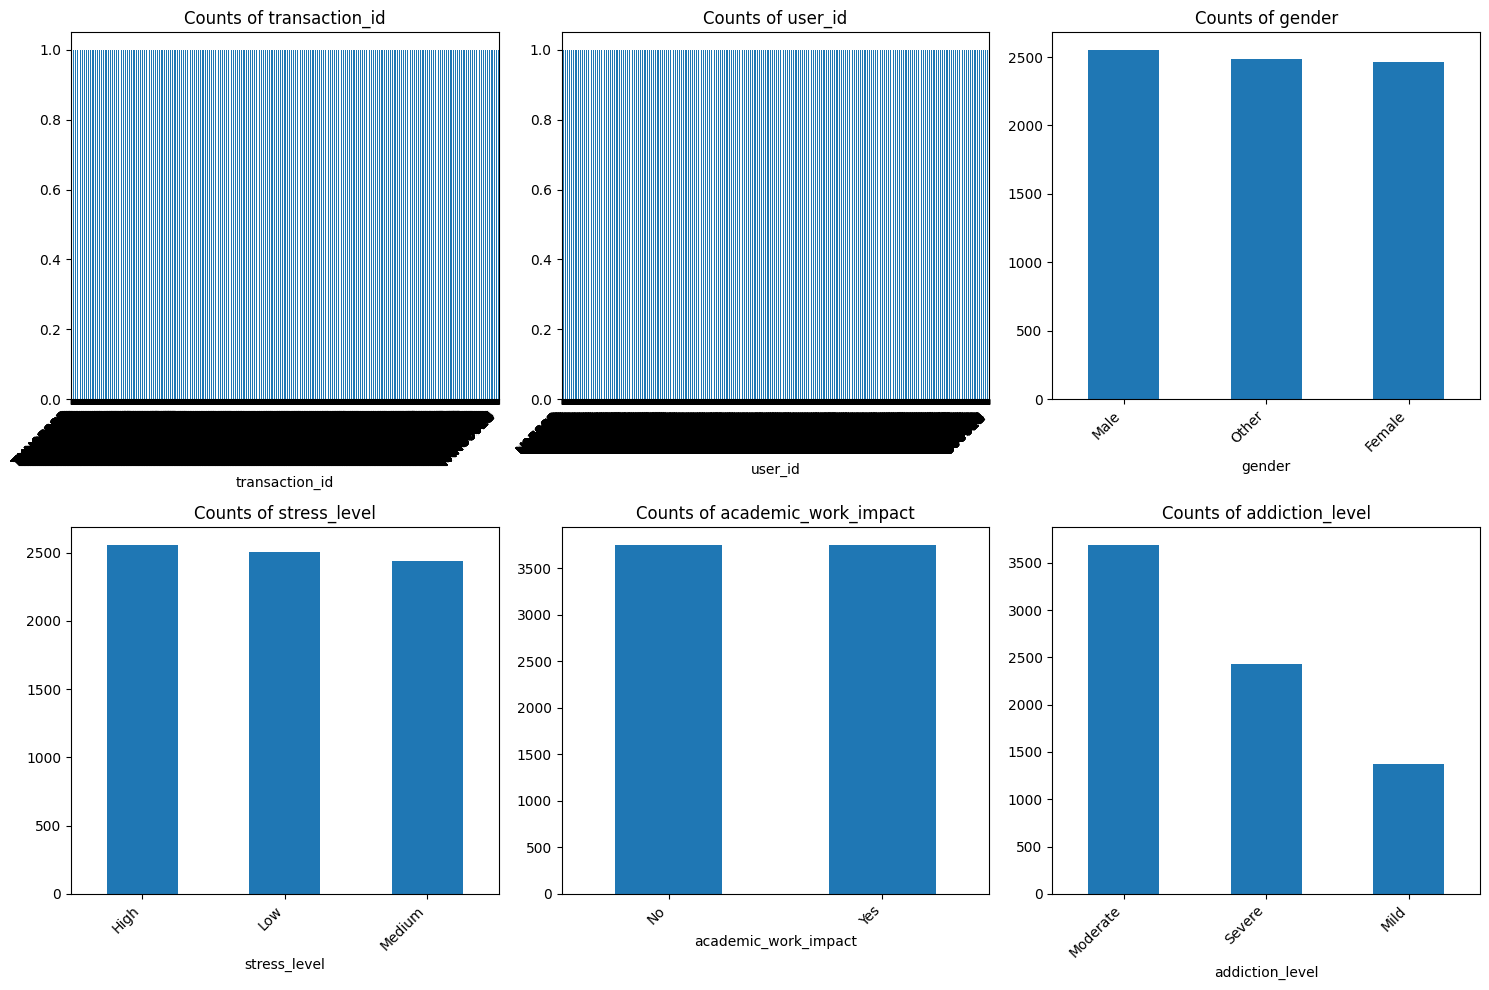

In [10]:
# Histograms for numerical columns
if not numerical_cols.empty:
    print("\nHistograms for numerical features:")
    num_rows = (len(numerical_cols) + 2) // 3
    plt.figure(figsize=(15, 5 * num_rows))
    for i, col in enumerate(numerical_cols):
        plt.subplot(num_rows, 3, i + 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found for histograms.")

# Bar plots for categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if not categorical_cols.empty:
    print("\nBar plots for categorical features:")
    num_rows = (len(categorical_cols) + 2) // 3
    plt.figure(figsize=(15, 5 * num_rows))
    for i, col in enumerate(categorical_cols):
        plt.subplot(num_rows, 3, i + 1)
        df[col].value_counts().plot(kind='bar')
        plt.title(f'Counts of {col}')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found for bar plots.")